In [103]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import precision_score, accuracy_score, recall_score , f1_score
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer


In [104]:
df = pd.read_csv("/content/AI-Based Hiring Prediction System.csv")
df.sample(10)

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
443,444,Daniel Cline,"Java, C++, SQL, React",4,B.Tech,NaN,Software Engineer,Hire,46950,7,95
278,279,Trevor Freeman,"Cybersecurity, Networking, Ethical Hacking",6,M.Tech,AWS Certified,Cybersecurity Analyst,Hire,53165,8,100
208,209,Derrick Mendoza,"Cybersecurity, Ethical Hacking, Networking, Linux",1,M.Tech,Deep Learning Specialization,Cybersecurity Analyst,Hire,102390,6,70
374,375,Thomas Lee,"Cybersecurity, Linux, Ethical Hacking",3,B.Sc,AWS Certified,Cybersecurity Analyst,Hire,75300,5,80
499,500,Kyle Cole,"Java, SQL, C++, React",3,B.Tech,Deep Learning Specialization,Software Engineer,Reject,67414,0,60
255,256,Kathleen Foster,"NLP, Pytorch, TensorFlow",6,B.Tech,Deep Learning Specialization,AI Researcher,Hire,72164,4,100
46,47,Terry Burns,"SQL, Java, C++, React",4,MBA,AWS Certified,Software Engineer,Hire,50602,9,100
195,196,Kimberly Anderson,"Pytorch, Python",7,B.Tech,NaN,AI Researcher,Hire,42236,6,100
987,988,Anna Perez,"Pytorch, TensorFlow, NLP",2,M.Tech,Google ML,AI Researcher,Hire,76264,4,65
978,979,Hunter Higgins,"SQL, Deep Learning, Machine Learning",9,B.Sc,Google ML,Data Scientist,Hire,89128,0,100


In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Resume_ID               1000 non-null   int64 
 1   Name                    1000 non-null   object
 2   Skills                  1000 non-null   object
 3   Experience (Years)      1000 non-null   int64 
 4   Education               1000 non-null   object
 5   Certifications          726 non-null    object
 6   Job Role                1000 non-null   object
 7   Recruiter Decision      1000 non-null   object
 8   Salary Expectation ($)  1000 non-null   int64 
 9   Projects Count          1000 non-null   int64 
 10  AI Score (0-100)        1000 non-null   int64 
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [106]:
df.head()

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100


In [107]:
df['Certifications'] = df['Certifications'].fillna(df['Certifications'].mode()[0])


In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Resume_ID               1000 non-null   int64 
 1   Name                    1000 non-null   object
 2   Skills                  1000 non-null   object
 3   Experience (Years)      1000 non-null   int64 
 4   Education               1000 non-null   object
 5   Certifications          1000 non-null   object
 6   Job Role                1000 non-null   object
 7   Recruiter Decision      1000 non-null   object
 8   Salary Expectation ($)  1000 non-null   int64 
 9   Projects Count          1000 non-null   int64 
 10  AI Score (0-100)        1000 non-null   int64 
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [109]:
df.duplicated().sum().item()

0

In [110]:
df['Skills'] = df['Skills'].str.split(', ')

encoder = MultiLabelBinarizer()
encoded_df = pd.DataFrame(
    encoder.fit_transform(df["Skills"]),
    columns = encoder.classes_,
    index = df.index
)
df = pd.concat([df, encoded_df], axis=1)
df.drop('Skills', axis=1, inplace=True)
df.head()

,Resume_ID,Name,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100),...,Java,Linux,Machine Learning,NLP,Networking,Python,Pytorch,React,SQL,TensorFlow
0,1,Ashley Ali,10,B.Sc,Deep Learning Specialization,AI Researcher,Hire,104895,8,100,...,0,0,0,1,0,0,1,0,0,1
1,2,Wesley Roman,10,MBA,Google ML,Data Scientist,Hire,113002,1,100,...,0,0,1,0,0,1,0,0,1,0
2,3,Corey Sanchez,1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70,...,0,1,0,0,0,0,0,0,0,0
3,4,Elizabeth Carney,7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95,...,0,0,0,0,0,1,1,0,0,1
4,5,Julie Hill,4,PhD,Deep Learning Specialization,Software Engineer,Hire,87441,9,100,...,1,0,0,0,0,0,0,1,1,0


In [111]:
df_encode = pd.get_dummies(df["Education"], dtype=int,prefix="Education")
df = pd.concat([df,df_encode],axis=1)
df.drop('Education', axis=1, inplace=True)

In [112]:
df_encode = pd.get_dummies(df["Certifications"], dtype=int,prefix="Certifications")
df = pd.concat([df,df_encode],axis=1)
df.drop('Certifications', axis=1, inplace=True)

In [113]:
df_encode = pd.get_dummies(df["Job Role"], dtype=int,prefix="Job Role")
df = pd.concat([df,df_encode],axis=1)
df.drop('Job Role', axis=1, inplace=True)

In [114]:
df.sample(5)

,Resume_ID,Name,Experience (Years),Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100),C++,Cybersecurity,Deep Learning,...,Education_M.Tech,Education_MBA,Education_PhD,Certifications_AWS Certified,Certifications_Deep Learning Specialization,Certifications_Google ML,Job Role_AI Researcher,Job Role_Cybersecurity Analyst,Job Role_Data Scientist,Job Role_Software Engineer
609,610,Briana Burnett,8,Hire,76830,2,100,0,1,0,...,1,0,0,0,1,0,0,1,0,0
472,473,Carolyn Willis,0,Reject,40720,2,35,0,0,0,...,0,1,0,0,0,1,1,0,0,0
2,3,Corey Sanchez,1,Hire,71766,7,70,0,1,0,...,0,1,0,0,1,0,0,1,0,0
320,321,Jerome Sampson,5,Hire,114879,8,100,0,0,1,...,0,1,0,0,0,1,0,0,1,0
489,490,Deborah Ramirez,3,Hire,104405,9,95,0,0,1,...,0,0,1,0,1,0,0,0,1,0


In [115]:
df["Recruiter Decision"] = df["Recruiter Decision"].map({'Hire':1,'Reject':0})

In [116]:
df.head(9)

,Resume_ID,Name,Experience (Years),Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100),C++,Cybersecurity,Deep Learning,...,Education_M.Tech,Education_MBA,Education_PhD,Certifications_AWS Certified,Certifications_Deep Learning Specialization,Certifications_Google ML,Job Role_AI Researcher,Job Role_Cybersecurity Analyst,Job Role_Data Scientist,Job Role_Software Engineer
0,1,Ashley Ali,10,1,104895,8,100,0,0,0,...,0,0,0,0,1,0,1,0,0,0
1,2,Wesley Roman,10,1,113002,1,100,0,0,1,...,0,1,0,0,0,1,0,0,1,0
2,3,Corey Sanchez,1,1,71766,7,70,0,1,0,...,0,1,0,0,1,0,0,1,0,0
3,4,Elizabeth Carney,7,1,46848,0,95,0,0,0,...,0,0,0,1,0,0,1,0,0,0
4,5,Julie Hill,4,1,87441,9,100,0,0,0,...,0,0,1,0,1,0,0,0,0,1
5,6,Samantha Santos,10,1,47957,5,100,0,1,0,...,0,0,0,0,0,1,0,1,0,0
6,7,Tony Smith,4,1,66208,9,100,0,1,0,...,1,0,0,1,0,0,0,1,0,0
7,8,Anthony Harrison,3,1,103006,7,90,0,0,0,...,1,0,0,1,0,0,1,0,0,0
8,9,Nancy Jenkins,7,1,92270,3,100,0,0,0,...,0,1,0,0,1,0,0,1,0,0


<Axes: xlabel='Recruiter Decision', ylabel='count'>

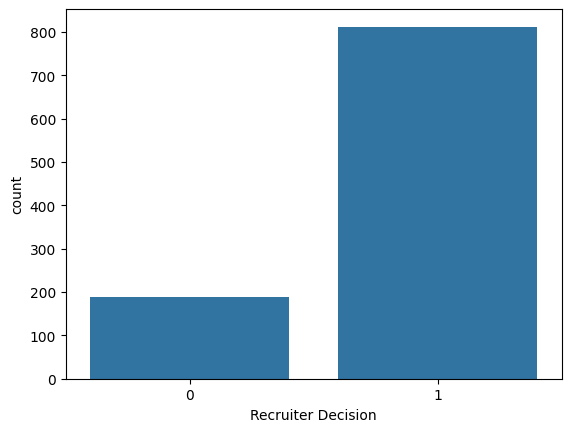

In [117]:
sns.countplot(x='Recruiter Decision', data=df)

In [118]:
x = df.drop(columns=["Resume_ID","Name","Recruiter Decision"])
y= df["Recruiter Decision"]

In [119]:
x_train ,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [120]:
scaller = StandardScaler()
x_train_s = scaller.fit_transform(x_train)
x_test_s = scaller.transform(x_test)

**Classification using Logistic Regression**

In [121]:
l_model = LogisticRegression(max_iter=3000)

In [122]:
l_model.fit(x_train_s,y_train)
l_y_pred = l_model.predict(x_test_s)

In [123]:
print("precision_score",precision_score(y_test,l_y_pred))
print("accuracy_score",accuracy_score(y_test,l_y_pred))
print("recall_score",recall_score(y_test,l_y_pred))
print("f1_score",f1_score(y_test,l_y_pred))



precision_score 0.9870967741935484
accuracy_score 0.985
recall_score 0.9935064935064936
f1_score 0.9902912621359223


**Classification using KNN classifier**

In [124]:
k_model = KNeighborsClassifier(n_neighbors=3 )


In [125]:
k_model.fit(x_train_s,y_train)
k_y_pred = k_model.predict(x_test_s)

In [126]:
print("precision_score",precision_score(y_test,k_y_pred))
print("accuracy_score",accuracy_score(y_test,k_y_pred))
print("recall_score",recall_score(y_test,k_y_pred))
print("f1_score",f1_score(y_test,k_y_pred))

precision_score 0.8982035928143712
accuracy_score 0.895
recall_score 0.974025974025974
f1_score 0.9345794392523364


**Classification using Randomforest**

In [130]:
r_model = RandomForestClassifier(n_estimators=150,random_state=42)

In [131]:
r_model.fit(x_train,y_train)
r_y_pred = r_model.predict(x_test)

In [132]:
print("precision_score",precision_score(y_test,r_y_pred))
print("accuracy_score",accuracy_score(y_test,r_y_pred))
print("recall_score",recall_score(y_test,r_y_pred))
print("f1_score",f1_score(y_test,r_y_pred))

precision_score 1.0
accuracy_score 1.0
recall_score 1.0
f1_score 1.0


In [133]:
results = pd.DataFrame({
    'Model':['Logistic Regression','KNN','Random Forest'],
    'Accuracy':[
        accuracy_score(y_test,l_y_pred),
        accuracy_score(y_test,k_y_pred),
        accuracy_score(y_test,r_y_pred)
    ],
    'F1':[
        f1_score(y_test,l_y_pred),
        f1_score(y_test,k_y_pred),
        f1_score(y_test,r_y_pred)
    ],
    'precision':[precision_score(y_test,l_y_pred),
                 precision_score(y_test,k_y_pred),
                 precision_score(y_test,r_y_pred)


    ]
})

results.sort_values('Accuracy', ascending=False)

,Model,Accuracy,F1,precision
2,Random Forest,1.000,1.000000,1.000000
0,Logistic Regression,0.985,0.990291,0.987097
1,KNN,0.895,0.934579,0.898204


In [134]:
importance = pd.Series(
    r_model.feature_importances_,
    index=x.columns
)

importance.sort_values(ascending=False).head(10)

,0
AI Score (0-100),0.601809
Experience (Years),0.213512
Projects Count,0.075994
Salary Expectation ($),0.033766
Python,0.005312
Certifications_Google ML,0.004468
Education_PhD,0.004173
Certifications_Deep Learning Specialization,0.003939
Education_MBA,0.003835
TensorFlow,0.003770
